<a href="https://colab.research.google.com/github/mpino3531-art/FACTURA/blob/main/Exploracion_Activos_YahooFinance_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Explorando activos financieros con Python y pandas
## Análisis exploratorio de activos de un portafolio

En este laboratorio aprenderás a obtener datos financieros, explorarlos con **pandas**, transformarlos y encontrar información útil para analizar activos.

> **Idea clave:** primero observamos los datos, después calculamos y finalmente interpretamos.


## 🧭 Ruta de aprendizaje

**1. Conectar con los datos** → Yahoo Finance y tickers  
**2. Conocer la información** → DataFrame y estructura  
**3. Mirar antes de calcular** → exploración inicial  
**4. Seguir el comportamiento** → precios y gráficos  
**5. Medir los cambios** → rendimientos  
**6. Describir lo encontrado** → estadísticas  
**7. Comparar para comprender** → varios activos  
**8. Buscar relaciones** → correlación  
**9. Tu análisis** → misión individual


# 1. 🔌 Conectar con los datos

### ¿De dónde obtenemos la información?

Yahoo Finance contiene información histórica de diferentes activos financieros. Para acceder a ella desde Python utilizaremos **yfinance**.

Un **ticker** es el código utilizado para identificar un activo. Por ejemplo: `AAPL`, `MSFT`, `AMZN` o `GOOGL`.


In [ ]:
!pip -q install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Nuestro primer activo

Comencemos con Apple. Más adelante cambiaremos el ticker para trabajar con los activos asignados.

In [ ]:
ticker = "AAPL"

datos = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

datos.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271538,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568909,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799911,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954933,75.797501,76.110001,74.290001,74.290001,132079200


# 2. 🧩 Conocer la información

Lo que acabamos de obtener es un **DataFrame de pandas**: una estructura de datos organizada en filas y columnas.

Antes de analizar, necesitamos saber qué contiene la tabla y cómo está organizada.


In [ ]:
datos.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271538,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568909,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799911,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954933,75.797501,76.110001,74.290001,74.290001,132079200


In [ ]:
datos.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-12-24,256.339752,258.200012,258.209991,255.289993,255.490005,23234700
2024-12-26,257.153839,259.019989,260.100006,257.630005,258.190002,27237100
2024-12-27,253.748535,255.589996,258.700012,253.059998,257.829987,42355300
2024-12-30,250.382965,252.199997,253.500000,250.750000,252.229996,35557500
2024-12-31,248.615799,250.419998,253.279999,249.429993,252.440002,39480700


In [ ]:
datos.shape

(1258, 6)

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  1258 non-null   float64
 1   (Close, AAPL)      1258 non-null   float64
 2   (High, AAPL)       1258 non-null   float64
 3   (Low, AAPL)        1258 non-null   float64
 4   (Open, AAPL)       1258 non-null   float64
 5   (Volume, AAPL)     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


### 🧠 Piensa

- ¿Qué representa una fila?
- ¿Qué representa una columna?
- ¿Qué información contiene el índice?
- ¿Cuántas observaciones tenemos?

Estas preguntas forman parte del **análisis exploratorio de datos**.

# 3. 🔎 Mirar antes de calcular

Una exploración inicial nos ayuda a detectar características, diferencias o posibles problemas antes de comenzar a realizar cálculos.

In [ ]:
datos.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.247343,154.108800,155.660348,152.379123,153.951948,9.057103e+07
std,41.815934,41.520877,41.654310,41.305929,41.466618,5.324438e+07
min,54.117035,56.092499,57.125000,53.152500,57.020000,2.323470e+07
25%,126.170277,129.624996,130.755005,127.505001,129.017506,5.546825e+07
50%,149.839409,152.805000,154.570000,150.825005,152.575005,7.628335e+07
75%,175.750465,178.850006,180.160000,177.115005,178.500004,1.077425e+08
max,257.153839,259.019989,260.100006,257.630005,258.190002,4.265100e+08


In [ ]:
datos.isna().sum()

### 🧠 Interpreta

No basta con ejecutar `describe()`. Observa los resultados y piensa: ¿qué nos permite conocer cada medida sobre los datos?

# 4. 📈 Seguir el comportamiento

Comencemos observando el precio de cierre. Una gráfica puede ayudarnos a identificar tendencias y cambios que serían difíciles de observar en una tabla.

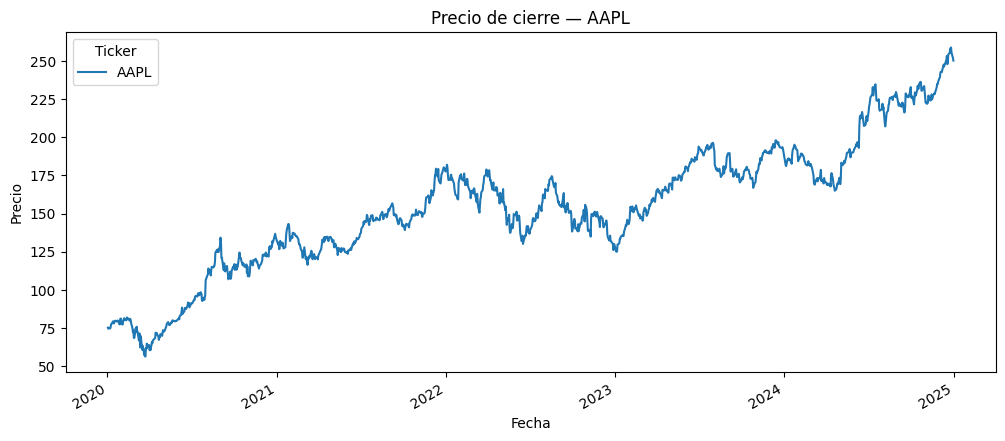

In [ ]:
cierre = datos["Close"]

cierre.plot(figsize=(12, 5))
plt.title(f"Precio de cierre — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

### 👀 Observa

Describe brevemente lo que encuentras:

- ¿Se observan períodos de crecimiento o disminución?
- ¿Hay cambios especialmente fuertes?
- ¿El comportamiento parece estable durante todo el período?


# 5. 🔄 Medir los cambios

Comparar solamente precios puede ser insuficiente porque los activos pueden comenzar con valores muy diferentes.

Una alternativa es estudiar los **rendimientos**, que expresan el cambio de una observación respecto a la anterior.


### Cálculo de Rendimientos Financieros

Existen dos formas principales de calcular los rendimientos financieros: discretos y logarítmicos.

#### 1. Rendimientos Discretos (o Simples)

Los rendimientos discretos representan el cambio porcentual en el precio de un activo entre dos períodos consecutivos. Son intuitivos y fáciles de interpretar, ya que reflejan directamente la ganancia o pérdida en relación con el precio inicial. Son adecuados para el cálculo de rendimientos de un solo período.

La fórmula para el rendimiento discreto $R_t$ en el período $t$ es:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_{t-1}$ es el precio del activo en el tiempo $t-1$.

### Ejemplo de Cálculo de Rendimientos

Consideremos los siguientes precios:
*   Precio Anterior ($P_{t-1}$): **100**
*   Precio Actual ($P_t$): **110**

#### 1. Cálculo del Rendimiento Discreto

Utilizando la fórmula:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{110 - 100}{100} = \frac{10}{100} = 0.10$$

El rendimiento discreto es **0.10** o **10%**.


In [ ]:
rendimiento = cierre.pct_change()
rendimiento.head()

Ticker,AAPL
Date,
2020-01-02,NaN
2020-01-03,-0.009722
2020-01-06,0.007968
2020-01-07,-0.004703
2020-01-08,0.016086


El primer valor aparece como `NaN` porque no existe una observación anterior con la cual compararlo.


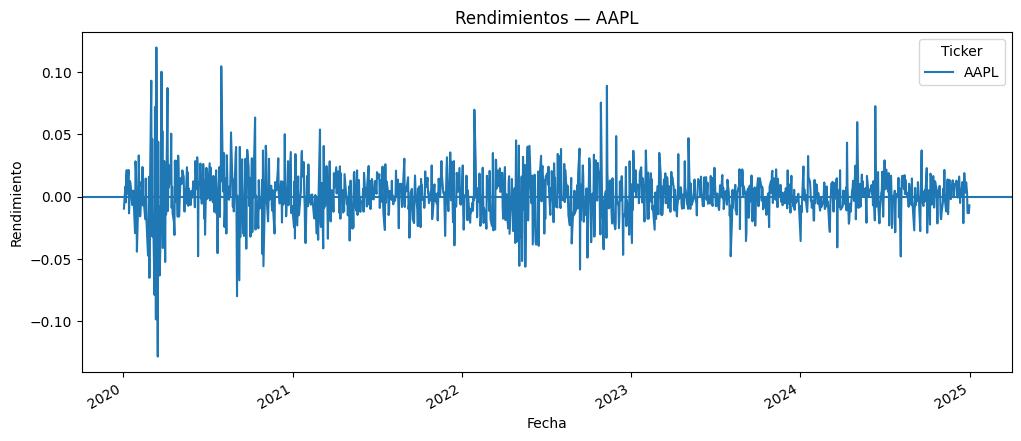

In [ ]:
rendimiento.plot(figsize=(12, 5))

plt.axhline(0)
plt.title(f"Rendimientos — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.show()

# 6. 📐 Describir lo encontrado

Ahora podemos utilizar las estadísticas descriptivas para conocer mejor la distribución de los rendimientos.

In [ ]:
rendimiento.describe()

Ticker,AAPL
count,1257.000000
mean,0.001157
std,0.019957
min,-0.128647
25%,-0.008425
50%,0.001172
75%,0.011989
max,0.119808


### Interpretación de las Estadísticas Descriptivas de Rendimientos

Al analizar la tabla de estadísticas descriptivas para los rendimientos, observamos lo siguiente:

*   **Promedio (Mean):** El promedio de los rendimientos es cercano a cero (aproximadamente 0.1157%). Esto sugiere que, a lo largo del periodo analizado, el rendimiento diario promedio del activo ha sido muy bajo, lo cual es común en series de rendimientos diarios que no muestran una tendencia marcada a largo plazo.

*   **Desviación Estándar (Std):** La desviación estándar es de aproximadamente 1.99%. Esta medida nos indica la dispersión o volatilidad de los rendimientos diarios. Un valor del 2% diario significa que, en promedio, los rendimientos suelen desviarse en un 2% (ya sea al alza o a la baja) de la media. En el contexto financiero, una mayor desviación estándar implica una mayor volatilidad y, por ende, un mayor riesgo.

*   **Mínimo (Min):** El rendimiento mínimo observado es de aproximadamente -12.86%. Esto representa la mayor pérdida porcentual experimentada por el activo en un solo día durante el periodo. Si se hubieran invertido 100 pesos, una pérdida del 12.86% implicaría que el valor de la inversión se reduciría a 87.14 pesos en ese día.

*   **Máximo (Max):** El rendimiento máximo observado es de aproximadamente 11.98%. Esta es la mayor ganancia porcentual en un solo día. Es notable que la máxima pérdida (-12.86%) es ligeramente superior a la máxima ganancia (11.98%), lo que podría indicar una asimetría en los movimientos extremos del activo, con pérdidas más severas en ciertos días.

*   **Percentil 25% (Q1):** El primer cuartil es de -0.84%. Esto significa que el 25% de los días, el rendimiento del activo fue igual o inferior a -0.84%, lo que implica una pérdida para el 25% de las observaciones.

*   **Percentil 50% (Mediana):** La mediana (percentil 50%) es de aproximadamente 0.1172%. Esto indica que el 50% de los rendimientos fueron iguales o inferiores a este valor, y el otro 50% fueron iguales o superiores. Al ser cercano a cero y ligeramente positivo, refuerza la idea de que los rendimientos oscilan alrededor de cero.

*   **Percentil 75% (Q3):** El tercer cuartil es de 1.19%. Esto significa que el 75% de los días, el rendimiento del activo fue igual o inferior a 1.19%, o dicho de otra forma, el 25% de los días la rentabilidad fue superior a 1.19%.

**Ausencia de tendencia y oscilación alrededor de cero:** Esto es típico en las series de rendimientos de activos. A diferencia de los precios, que suelen mostrar tendencias alcistas o bajistas a largo plazo, los rendimientos diarios (o periódicos) tienden a fluctuar en torno a su promedio (que a menudo es cercano a cero). Esto indica que, en el corto plazo, los movimientos positivos y negativos se compensan, sin una dirección clara y sostenida.

**Dispersión alrededor de cero y su variabilidad (Volatilidad)**: Has identificado correctamente que la dispersión de los rendimientos alrededor de cero no es constante. Esta dispersión se mide con la desviación estándar, y en el ámbito financiero se conoce como volatilidad. Una mayor dispersión (picos más altos o valles más profundos) significa mayor volatilidad, lo que implica que el precio del activo está experimentando cambios más grandes en un corto período de tiempo. Los periodos de "alta dispersión" se correlacionan con alta volatilidad (mayor riesgo), mientras que los de "baja dispersión" indican baja volatilidad (menor riesgo).

**Rangos de máximos y mínimos (Variabilidad Extrema):** La observación de que los rendimientos máximos superan el 10% y los mínimos caen por debajo del -10% es crucial. Esto te da una idea del rango extremo de movimientos que el activo ha experimentado en un solo día. Rendimientos tan altos o tan bajos en un solo día son eventos significativos que reflejan la magnitud de los shocks o noticias que afectaron al activo en esos momentos.

# Percentiles extremos


In [ ]:
print("Percentil 1:", rendimiento.quantile(0.01))
print("Percentil 5:", rendimiento.quantile(0.05))

Percentil 1: Ticker
AAPL   -0.050317
Name: 0.01, dtype: float64
Percentil 5: Ticker
AAPL   -0.030125
Name: 0.05, dtype: float64


## Interpretación de Percentiles como Pérdida Máxima Esperada (VaR)

Los percentiles 1 y 5 de los rendimientos son a menudo interpretados en el contexto de **Valor en Riesgo (VaR)**, una medida clave en finanzas para cuantificar la pérdida potencial de una inversión.

*   El **percentil 1** de aproximadamente -0.050317 (-5.03%) significa que existe un **1% de probabilidad** de que el activo experimente una pérdida de 5.03% o más de su valor en un día determinado, bajo condiciones normales de mercado. Esto se puede entender como la **máxima pérdida esperada** que el activo podría sufrir con un nivel de confianza del 99% (es decir, hay solo un 1% de posibilidades de que la pérdida real sea mayor).

*   El **percentil 5** de aproximadamente -0.030125 (-3.01%) significa que existe un **5% de probabilidad** de que el activo experimente una pérdida de 3.01% o más de su valor en un día determinado. Esto se interpreta como la **máxima pérdida esperada** con un nivel de confianza del 95% (hay un 5% de posibilidades de que la pérdida real sea mayor).

En resumen, estos valores proporcionan una estimación de las pérdidas extremas que un inversor podría enfrentar con este activo en un día, junto con la probabilidad de que ocurran.

In [ ]:
print("Promedio:", rendimiento.mean())
print("Desviación estándar:", rendimiento.std())
print("Mínimo:", rendimiento.min())
print("Máximo:", rendimiento.max())

Promedio: Ticker
AAPL    0.001157
dtype: float64
Desviación estándar: Ticker
AAPL    0.019957
dtype: float64
Mínimo: Ticker
AAPL   -0.128647
dtype: float64
Máximo: Ticker
AAPL    0.119808
dtype: float64


### 🧠 Interpreta

¿Qué nos dice el promedio? ¿Qué información aporta la desviación estándar? ¿Qué representan los valores mínimo y máximo?

Recuerda: **una estadística tiene sentido cuando podemos explicar qué significa en el contexto financiero.**

# 7. ⚖️ Comparar para comprender

Ahora incorporaremos varios activos. La comparación nos permitirá observar diferencias en su comportamiento.

In [ ]:
activos = ["AAPL", "MSFT", "AMZN"]

datos = yf.download(
    activos,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

precios = datos["Close"]
precios.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-02,75.087502,94.900497,160.619995
2020-01-03,74.357498,93.748497,158.619995
2020-01-06,74.949997,95.143997,159.029999
2020-01-07,74.597504,95.343002,157.580002
2020-01-08,75.797501,94.598503,160.089996


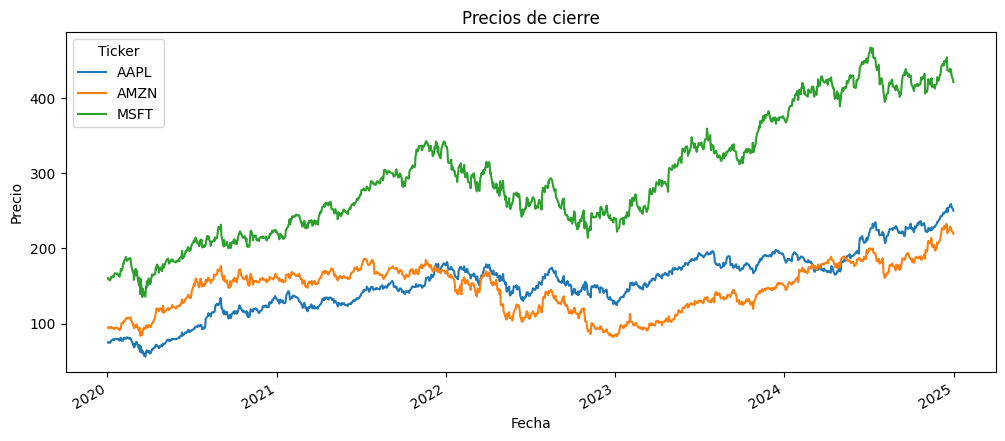

In [ ]:
precios.plot(figsize=(12, 5))

plt.title("Precios de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

Los precios pueden tener escalas diferentes. Para comparar su evolución desde un mismo punto de referencia podemos construir un índice base 100.

### Normalización de Precios (Base 100)

Para comparar la evolución de diferentes activos financieros, es útil **normalizar sus precios a una base común**, como 100. Esto permite observar cómo ha crecido o disminuido el valor de cada activo desde un punto de partida equitativo, independientemente de sus precios absolutos iniciales.

La fórmula para normalizar un precio $P_t$ en el tiempo $t$ a una base 100 es:

$$\Large P_{t, \text{normalizado}} = \frac{P_t}{P_0} \times 100$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_0$ es el precio inicial (o precio en el punto de partida) del activo.

#### Ejemplo:

Supongamos que tenemos los siguientes precios para un activo en tres días:

*   Día 1 ($P_0$): **75.00**
*   Día 2 ($P_1$): **74.35**
*   Día 3 ($P_2$): **74.95**

Aplicando la fórmula de normalización:

*   **Día 1:** $\frac{75.00}{75.00} \times 100 = 100$
*   **Día 2:** $\frac{74.35}{75.00} \times 100 \approx 99.13$
*   **Día 3:** $\frac{74.95}{75.00} \times 100 \approx 99.93$

Estos valores normalizados nos permiten ver el cambio porcentual relativo de cada día respecto al día inicial (base 100).

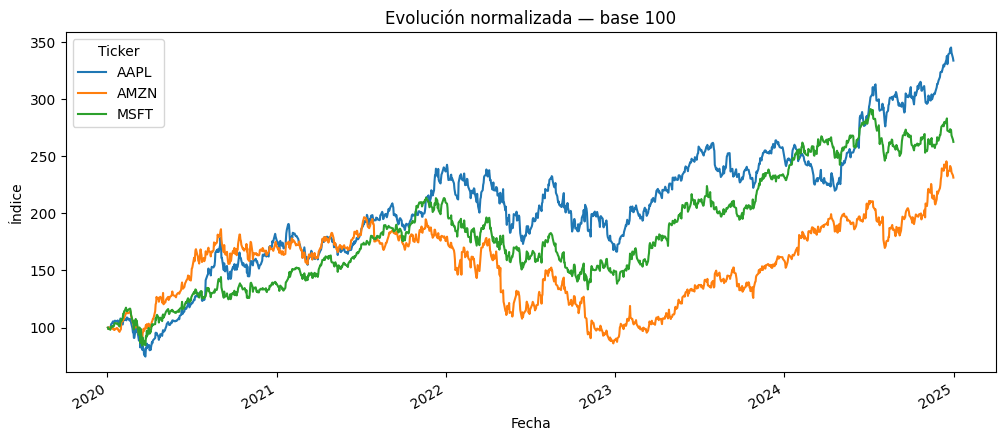

In [ ]:
precios_normalizados = precios / precios.iloc[0] * 100

precios_normalizados.plot(figsize=(12, 5))
plt.title("Evolución normalizada — base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()

# 8. 🔗 Buscar relaciones

En un portafolio no solo importa cómo se comporta cada activo individualmente. También interesa saber cómo se relacionan entre sí.

Primero calculamos los rendimientos de todos los activos.

In [ ]:
rendimientos = precios.pct_change()
rendimientos.head()

Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012139,-0.012452
2020-01-06,0.007968,0.014886,0.002585
2020-01-07,-0.004703,0.002092,-0.009118
2020-01-08,0.016086,-0.007809,0.015928


In [ ]:
correlacion = rendimientos.corr()
correlacion

Ticker,AAPL,AMZN,MSFT
Ticker,,,
AAPL,1.000000,0.591883,0.748121
AMZN,0.591883,1.000000,0.678666
MSFT,0.748121,0.678666,1.000000


### Análisis Financiero de la Matriz de Correlación

La matriz de correlación de los rendimientos es una herramienta fundamental en finanzas para entender la relación entre los movimientos de diferentes activos y es clave para la **diversificación de carteras**.

*   **Correlación Positiva (cercana a +1):** Indica que los rendimientos de los activos tienden a moverse en la misma dirección. Si el rendimiento de un activo sube, es muy probable que el del otro también lo haga, y viceversa. En nuestra matriz, podemos observar una fuerte correlación positiva entre **AAPL y MSFT (0.748)**. Esto significa que si las acciones de Apple suben, las de Microsoft probablemente también lo harán, y si bajan, las de Microsoft también tenderán a bajar. Una correlación alta reduce los beneficios de la diversificación, ya que los activos no actúan como "amortiguadores" el uno del otro en momentos de caída.

*   **Correlación Negativa (cercana a -1):** Sugiere que los rendimientos de los activos tienden a moverse en direcciones opuestas. Si un activo sube, el otro tiende a bajar, y viceversa. Este tipo de correlación es muy deseable para la diversificación, ya que ayuda a mitigar el riesgo de la cartera. En nuestra matriz, no observamos correlaciones negativas fuertes, lo cual es común entre acciones del mismo sector o mercado.

*   **Correlación Cero (cercana a 0):** Implica que no hay una relación lineal predecible entre los movimientos de los rendimientos de los activos. Su comportamiento es independiente el uno del otro. Aunque no reduce el riesgo tan eficazmente como una correlación negativa, sigue siendo beneficioso para la diversificación en comparación con una correlación positiva alta.

#### Implicaciones para la Diversificación:

Para construir un portafolio robusto y diversificado, se busca incluir activos con **baja o negativa correlación**. Esto se debe a que, si un activo experimenta una caída, es probable que otro activo con baja o negativa correlación no caiga (o incluso suba), compensando así parte de la pérdida. Los activos en nuestra matriz muestran correlaciones positivas entre sí, lo que sugiere que son algo dependientes. Por ejemplo, **AAPL** y **AMZN** tienen una correlación de **0.592**, y **AMZN** y **MSFT** de **0.679**. Esto indica que, aunque no se mueven en perfecta sintonía, sus rendimientos sí comparten una tendencia común.

Para mejorar la diversificación, un inversor podría considerar añadir activos de diferentes sectores, geografías o tipos (por ejemplo, bonos, materias primas) que históricamente muestren una correlación más baja o negativa con los activos tecnológicos actuales.

### ¿Cómo podemos leer la correlación?

- Cerca de **1**: los movimientos tienden a ser similares.
- Cerca de **0**: la relación lineal es débil.
- Cerca de **-1**: los movimientos tienden a ser opuestos.

### 💭 Pregunta

Si dos activos presentan una correlación elevada, ¿qué podría significar esto al pensar en diversificación?

# 9. 🚀 Tu análisis

Ahora repite el proceso con los **activos que te fueron asignados**.

Tu análisis debe seguir esta secuencia:

**Obtener → Conocer → Explorar → Transformar → Describir → Comparar → Relacionar → Interpretar**

### Tu misión

1. Obtén los datos históricos desde Yahoo Finance.
2. Explora la estructura del DataFrame.
3. Revisa los datos y los valores faltantes.
4. Observa el comportamiento de los precios.
5. Calcula los rendimientos.
6. Describe los rendimientos con estadísticas.
7. Compara visualmente los activos.
8. Explora la correlación.
9. Escribe una conclusión sustentada en los resultados.

> **Pregunta final:** ¿Qué diferencias encontraste entre los activos y qué información consideras importante conocer antes de incorporarlos a un portafolio?


## 🎫 Salida de aprendizaje

Completa estas tres frases en una celda de texto:

- **Encontré que…**
- **La información que más me ayudó a comparar los activos fue…**
- **Antes de construir un portafolio, considero importante revisar…**


Datos descargados correctamente.
Tamaño del DataFrame: (250, 30)
Primeras filas:


Price            Close                                               \
Ticker              BA        BAC        COP       CSCO         MCD   
Date                                                                  
2025-01-02  171.869995  42.604233  94.647316  56.786293  280.347382   
2025-01-03  169.899994  43.104439  95.602493  56.941082  282.522980   
2025-01-06  170.779999  43.671986  94.562210  56.854012  280.031128   
2025-01-07  172.509995  44.326103  96.151001  57.008801  277.309204   
2025-01-08  171.759995  44.451157  96.103729  57.269993  274.970642   

Price                        High                                   ...  \
Ticker            MRK          BA        BAC        COP       CSCO  ...   
Date                                                                ...   
2025-01-02  93.644005  179.190002  42.892813  95.782173  57.343588  ...   
2025-01-03  93.615677  173.979996  43.142914  95.895670  57.240973  ...   
2025-01-06  94.163353  173.940002  44.393439  96.604962  57.637606  ...   
2025-01-07  95.390923  175.020004  44.874408  96.926488  57.318368  ...   
2025-01-08  94.286118  173.779999  44.499253  96.888669  57.308690  ...   

Price            Open                                      Volume            \
Ticker            COP       CSCO         MCD        MRK        BA       BAC   
Date                                                                          
2025-01-02  94.571657  56.949640  278.852249  94.692154  12450000  25610600   
2025-01-03  95.158013  56.921734  280.654049  93.804530  10513800  23455700   
2025-01-06  96.037533  56.989447  281.085396  93.266285  11133400  30518500   
2025-01-07  95.044514  57.047497  281.564591  94.550516   7045000  41111200   
2025-01-08  95.517382  56.970098  276.954578  95.088752   5108700  40246000   

Price                                             
Ticker          COP      CSCO      MCD       MRK  
Date                                              
2025-01-02  5080600  16144300  3117000   6153300  
2025-01-03  5758200  18859000  2240100   6070300  
2025-01-06  5935500  18543300  2838900  10111100  
2025-01-07  5074700  16863800  3419500  10890900  
2025-01-08  5119900  14400300  2724200   8654700  

[5 rows x 30 columns]


Últimas filas:


Price            Close                                               \
Ticker              BA        BAC        COP       CSCO         MCD   
Date                                                                  
2025-12-24  218.160004  55.362221  89.820076  76.898811  307.306061   
2025-12-26  216.440002  55.283478  89.565674  77.036797  304.707031   
2025-12-29  217.250000  54.476418  90.632164  76.672112  302.598328   
2025-12-30  218.500000  54.407528  92.070465  76.297585  302.107941   
2025-12-31  217.119995  54.131947  91.591034  75.923035  299.754089   

Price                         High                                   ...  \
Ticker             MRK          BA        BAC        COP       CSCO  ...   
Date                                                                 ...   
2025-12-24  104.297249  219.270004  55.608275  91.150744  77.164936  ...   
2025-12-26  104.620575  218.669998  55.657481  90.485402  77.155067  ...   
2025-12-29  104.463821  218.139999  55.362214  90.730013  77.174785  ...   
2025-12-30  103.915138  221.880005  54.761847  92.275935  76.691830  ...   
2025-12-31  103.131317  219.320007  54.545316  92.549893  76.701683  ...   

Price            Open                                      Volume            \
Ticker            COP       CSCO         MCD         MRK       BA       BAC   
Date                                                                          
2025-12-24  90.749584  76.898811  304.707014  103.239095  2943500  13634400   
2025-12-26  89.927696  76.977654  306.962831  104.297247  2801500  15259400   
2025-12-29  90.015754  76.908660  304.491215  104.689166  5292000  21040100   
2025-12-30  91.336641  76.691830  301.176193  104.571594  5653500  17427600   
2025-12-31  92.412913  76.228577  301.862748  103.797566  5563000  16293000   

Price                                            
Ticker          COP      CSCO      MCD      MRK  
Date                                             
2025-12-24  3079200   9104400  1011500  5335000  
2025-12-26  4575600  10158000  1308900  6280700  
2025-12-29  5256400  17941800  2148300  8086900  
2025-12-30  4553600  13952200  1678300  6497900  
2025-12-31  3551700  13570500  1903600  7557300  

[5 rows x 30 columns]


Información de los datos:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-01-02 to 2025-12-31
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, BA)     250 non-null    float64
 1   (Close, BAC)    250 non-null    float64
 2   (Close, COP)    250 non-null    float64
 3   (Close, CSCO)   250 non-null    float64
 4   (Close, MCD)    250 non-null    float64
 5   (Close, MRK)    250 non-null    float64
 6   (High, BA)      250 non-null    float64
 7   (High, BAC)     250 non-null    float64
 8   (High, COP)     250 non-null    float64
 9   (High, CSCO)    250 non-null    float64
 10  (High, MCD)     250 non-null    float64
 11  (High, MRK)     250 non-null    float64
 12  (Low, BA)       250 non-null    float64
 13  (Low, BAC)      250 non-null    float64
 14  (Low, COP)      250 non-null    float64
 15  (Low, CSCO)     250 non-null    float64
 16  (Low, MCD)      250 non-null    fl

Ticker,BA,BAC,COP,CSCO,MCD,MRK
Date,,,,,,
2025-01-02,171.869995,42.604233,94.647316,56.786293,280.347382,93.644005
2025-01-03,169.899994,43.104439,95.602493,56.941082,282.522980,93.615677
2025-01-06,170.779999,43.671986,94.562210,56.854012,280.031128,94.163353
2025-01-07,172.509995,44.326103,96.151001,57.008801,277.309204,95.390923
2025-01-08,171.759995,44.451157,96.103729,57.269993,274.970642,94.286118


Ticker          BA         BAC         COP        CSCO         MCD         MRK
count   250.000000  250.000000  250.000000  250.000000  250.000000  250.000000
mean    198.752680   45.871867   89.998870   64.943555  295.051395   83.704832
std      23.839487    4.944053    4.631478    6.361029    9.479656    7.953765
min     136.589996   33.289810   78.807312   51.799469  268.108307   69.975418
25%     179.112499   42.880315   86.249399   59.790070  290.033676   77.688696
50%     202.125000   45.467525   90.214981   65.660408  296.189621   81.642902
75%     217.109997   49.874379   93.002689   67.989620  302.263992   89.185574
max     237.380005   55.362221  101.154778   79.096764  313.504578  104.620575


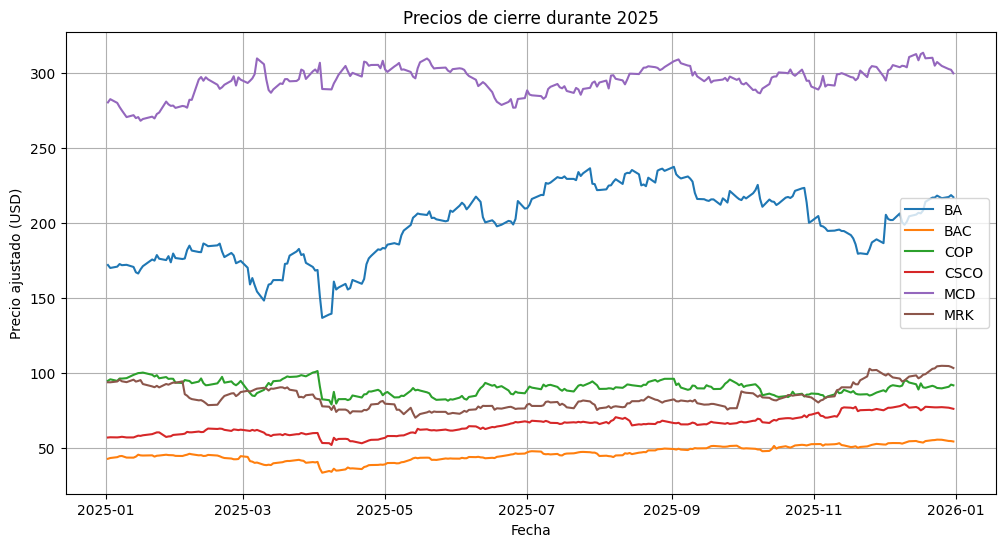

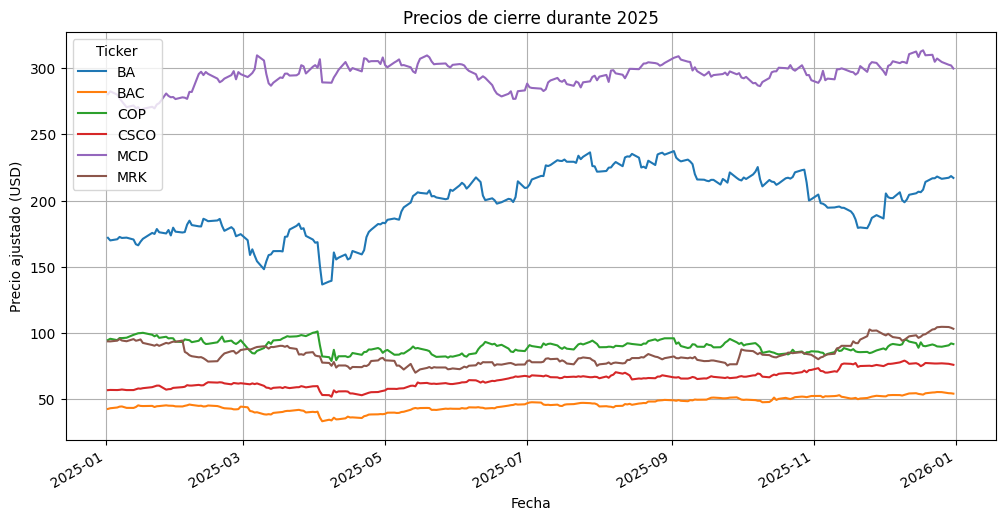

Ticker,BA,BAC,COP,CSCO,MCD,MRK
Date,,,,,,
2025-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-03,-0.011462,0.011741,0.010092,0.002726,0.007760,-0.000303
2025-01-06,0.005180,0.013167,-0.010881,-0.001529,-0.008820,0.005850
2025-01-07,0.010130,0.014978,0.016802,0.002723,-0.009720,0.013037
2025-01-08,-0.004348,0.002821,-0.000492,0.004582,-0.008433,-0.011582


Ticker,BA,BAC,COP,CSCO,MCD,MRK
Date,,,,,,
2025-01-03,-0.011462,0.011741,0.010092,0.002726,0.007760,-0.000303
2025-01-06,0.005180,0.013167,-0.010881,-0.001529,-0.008820,0.005850
2025-01-07,0.010130,0.014978,0.016802,0.002723,-0.009720,0.013037
2025-01-08,-0.004348,0.002821,-0.000492,0.004582,-0.008433,-0.011582
2025-01-10,0.001397,-0.023804,0.002952,-0.007770,-0.015999,-0.006009


,promedio,desviacion_estandar,minimo,maximo
Ticker,,,,
BA,0.001216,0.023708,-0.104710,0.153741
BAC,0.001106,0.016859,-0.110633,0.060520
COP,0.000097,0.021299,-0.102262,0.107065
CSCO,0.001279,0.014984,-0.066764,0.092875
MCD,0.000337,0.011680,-0.057058,0.047979
MRK,0.000571,0.019150,-0.090691,0.073871


,promedio,desviacion_estandar,minimo,maximo
Ticker,,,,
BA,0.1216,2.3708,-10.4710,15.3741
BAC,0.1106,1.6859,-11.0633,6.0520
COP,0.0097,2.1299,-10.2262,10.7065
CSCO,0.1279,1.4984,-6.6764,9.2875
MCD,0.0337,1.1680,-5.7058,4.7979
MRK,0.0571,1.9150,-9.0691,7.3871


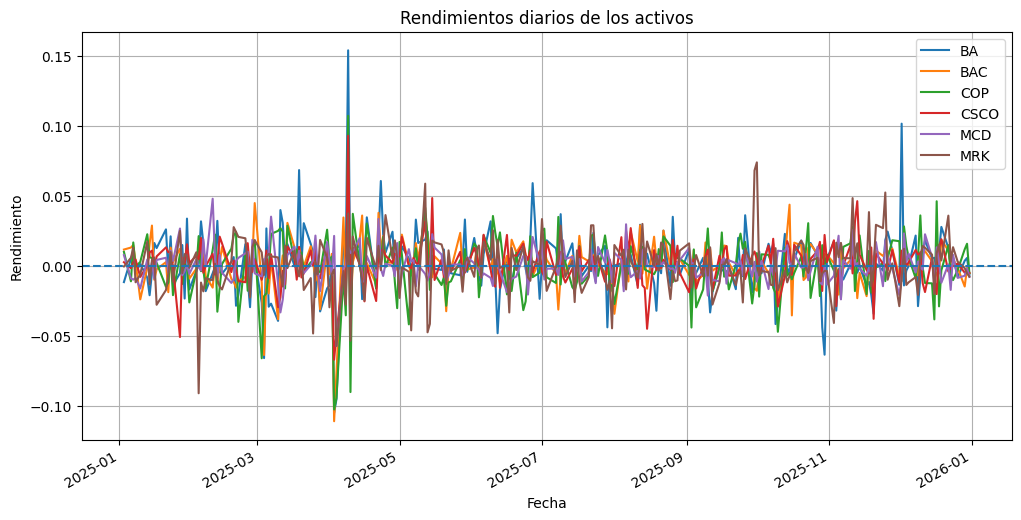

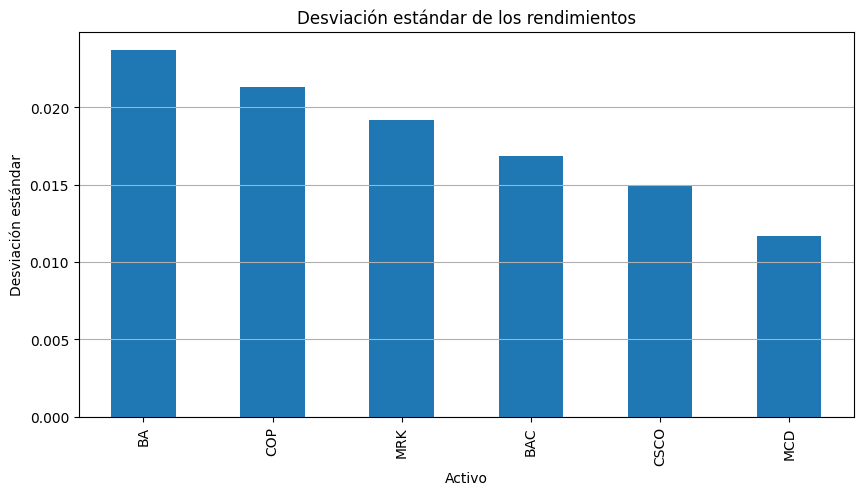

Ticker,BA,BAC,COP,CSCO,MCD,MRK
Ticker,,,,,,
BA,1.000,0.498,0.393,0.438,0.062,0.133
BAC,0.498,1.000,0.491,0.524,0.106,0.155
COP,0.393,0.491,1.000,0.342,0.113,0.247
CSCO,0.438,0.524,0.342,1.000,0.106,0.126
MCD,0.062,0.106,0.113,0.106,1.000,0.248
MRK,0.133,0.155,0.247,0.126,0.248,1.000


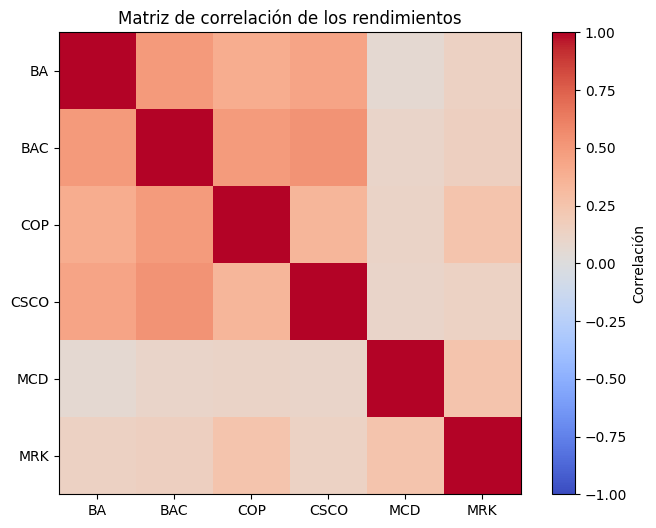

Peor día de cada activo:
Ticker
BA     2025-04-03
BAC    2025-04-03
COP    2025-04-03
CSCO   2025-04-03
MCD    2025-04-04
MRK    2025-02-04
dtype: datetime64[ns]

Mejor día de cada activo:
Ticker
BA     2025-04-09
BAC    2025-04-09
COP    2025-04-09
CSCO   2025-04-09
MCD    2025-02-10
MRK    2025-10-01
dtype: datetime64[ns]
Peor rendimiento diario:
Ticker
BA     -10.47
BAC    -11.06
COP    -10.23
CSCO    -6.68
MCD     -5.71
MRK     -9.07
dtype: float64

Mejor rendimiento diario:
Ticker
BA      15.37
BAC      6.05
COP     10.71
CSCO     9.29
MCD      4.80
MRK      7.39
dtype: float64


,rendimiento_promedio_%,riesgo_%,peor_dia_%,mejor_dia_%
Ticker,,,,
BA,0.122,2.371,-10.471,15.374
BAC,0.111,1.686,-11.063,6.052
COP,0.010,2.130,-10.226,10.706
CSCO,0.128,1.498,-6.676,9.287
MCD,0.034,1.168,-5.706,4.798
MRK,0.057,1.915,-9.069,7.387


In [19]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Activos asignados
tickers = ["CSCO", "BAC", "COP", "MRK", "MCD", "BA"]

# Descargar datos de 2025
precios = yf.download(
    tickers,
    start="2025-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

print("Datos descargados correctamente.")
print("Tamaño del DataFrame:", precios.shape)

print("Primeras filas:")
display(precios.head())

print("\nÚltimas filas:")
display(precios.tail())

print("\nInformación de los datos:")
precios.info()

cierre = precios["Close"]

display(cierre.head())

print(cierre.describe())

plt.figure(figsize=(12, 6))

for columna in cierre.columns:
    plt.plot(cierre.index, cierre[columna], label=columna)

plt.title("Precios de cierre durante 2025")
plt.xlabel("Fecha")
plt.ylabel("Precio ajustado (USD)")
plt.legend()
plt.grid(True)
plt.show()

cierre.plot(figsize=(12, 6))

plt.title("Precios de cierre durante 2025")
plt.xlabel("Fecha")
plt.ylabel("Precio ajustado (USD)")
plt.grid(True)
plt.show()

rendimiento = cierre.pct_change()

display(rendimiento.head())
rendimiento = rendimiento.dropna()

display(rendimiento.head())
estadisticas = pd.DataFrame({
    "promedio": rendimiento.mean(),
    "desviacion_estandar": rendimiento.std(),
    "minimo": rendimiento.min(),
    "maximo": rendimiento.max()
})

display(estadisticas)
estadisticas_porcentaje = estadisticas * 100

display(estadisticas_porcentaje.round(4))

rendimiento.plot(figsize=(12, 6))

plt.axhline(0, linestyle="--")
plt.title("Rendimientos diarios de los activos")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.legend()
plt.grid(True)
plt.show()

estadisticas["desviacion_estandar"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Desviación estándar de los rendimientos")
plt.xlabel("Activo")
plt.ylabel("Desviación estándar")
plt.grid(axis="y")
plt.show()

correlacion = rendimiento.corr()

display(correlacion.round(3))

plt.figure(figsize=(8, 6))

plt.imshow(correlacion, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(range(len(correlacion.columns)), correlacion.columns)
plt.yticks(range(len(correlacion.index)), correlacion.index)

plt.colorbar(label="Correlación")
plt.title("Matriz de correlación de los rendimientos")

plt.show()

peor_dia = rendimiento.idxmin()
mejor_dia = rendimiento.idxmax()

print("Peor día de cada activo:")
print(peor_dia)

print("\nMejor día de cada activo:")
print(mejor_dia)

print("Peor rendimiento diario:")
print((rendimiento.min() * 100).round(2))

print("\nMejor rendimiento diario:")
print((rendimiento.max() * 100).round(2))

comparacion = pd.DataFrame({
    "rendimiento_promedio_%": rendimiento.mean() * 100,
    "riesgo_%": rendimiento.std() * 100,
    "peor_dia_%": rendimiento.min() * 100,
    "mejor_dia_%": rendimiento.max() * 100
})

comparacion = comparacion.round(3)

display(comparacion)

**Encontré que…** los seis activos analizados (CSCO, BAC, COP, MRK, MCD y BA) presentan comportamientos diferentes tanto en sus precios como en sus rendimientos diarios. También observé que algunos activos tienen mayor variabilidad que otros, lo que permite identificar diferencias en el nivel de riesgo.

**La información que más me ayudó a comparar los activos fue…** el promedio de los rendimientos, la desviación estándar, los valores mínimo y máximo y la matriz de correlación. Estas medidas permiten comparar el comportamiento de los activos y observar cuáles presentan mayor o menor variación en el periodo analizado.

**Antes de construir un portafolio, considero importante revisar…** el rendimiento esperado, el nivel de riesgo, la relación entre los activos mediante la correlación y los posibles cambios extremos en los precios. También es importante tener en cuenta que los resultados históricos corresponden al periodo analizado y no garantizan que el mismo comportamiento se repita en el futuro.
